cd "D:\1.0 project\NLP1"

py -3.11 -m venv nlp_project1
.\nlp_project1\Scripts\Activate.ps1

python -m pip install --upgrade pip setuptools wheel

pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
pip install numpy==1.26.4 pandas==2.2.2
pip install transformers==4.40.0 peft==0.10.0 datasets==2.19.0 accelerate==0.29.3
pip install scikit-learn matplotlib seaborn tqdm evaluate openpyxl scipy sentencepiece jupyterlab ipykernel

python -m ipykernel install --user --name nlp_project1 --display-name "Python (nlp_project1)"
python -c "import torch; print(torch.__version__); print(torch.cuda.is_available()); print(torch.version.cuda); print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO CUDA')"


In [1]:
# ============================================================
# CELL 1: Check All DEPENDENCIES
# ============================================================
import sys
import torch
import numpy as np
import pandas as pd
import transformers

print("Python version:", sys.version)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO CUDA")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Transformers version:", transformers.__version__)

d:\1.0 project\NLP1\nlp_project1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Torch version: 2.7.1+cu118
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2060
NumPy version: 1.26.4
Pandas version: 2.2.2
Transformers version: 4.40.0


In [2]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO CUDA")


Torch version: 2.7.1+cu118
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2060


In [3]:
# ============================================================
# CELL 1: LOCAL ENVIRONMENT NOTE
# ============================================================
print("Using local Windows venv: dependencies already installed.")
print("Skip pip installs inside the notebook.")

Using local Windows venv: dependencies already installed.
Skip pip installs inside the notebook.


In [4]:
# ============================================================
# CELL 2: IMPORTS + GPU CHECK + SEED
# ============================================================
import os, sys, time, json, re, random, warnings, gc, unicodedata
from datetime import datetime
from collections import Counter, defaultdict
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from tqdm.auto import tqdm
from scipy import stats

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, set_seed,
    DataCollatorWithPadding
)
from peft import (
    PromptTuningConfig, PromptTuningInit,
    PrefixTuningConfig, PromptEncoderConfig,
    TaskType, get_peft_model
)
from datasets import load_dataset, Dataset as HFDataset, DatasetDict
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    vram_gb = gpu_props.total_memory / (1024 ** 3)
    print(f"  GPU: {gpu_name} | VRAM: {vram_gb:.2f} GB")

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def clear_gpu():
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"clear_gpu warning: {e}")

print("✅ All imports OK")


W0329 14:10:00.482000 16612 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Device: cuda
  GPU: NVIDIA GeForce RTX 2060 | VRAM: 6.00 GB
✅ All imports OK


In [5]:
# ============================================================
# CELL 3: CONFIGURATION — RTX 2060 6GB (Windows 11)
# ============================================================

CFG = {
    'model_name': 'xlm-roberta-base',

    'max_len': 128,
    'batch_size': 4,
    'grad_accum': 4,

    'epochs_ft': 5,
    'epochs_pt': 12,

    'lr_ft': 2e-5,
    'lr_pt': 3e-4,
    'warmup': 0.1,
    'weight_decay': 0.01,
    'patience': 3,

    'num_virtual_tokens': 50,

    'sample_sizes': [100, 500, 1000, 5000],
    'ablation_lengths': [10, 20, 50, 100],

    'output_dir': './results',
    'save_dir': './saved_models',

    'TEST_MODE': False,
}

os.makedirs(CFG['output_dir'], exist_ok=True)
os.makedirs(CFG['save_dir'], exist_ok=True)

print("FINAL TRAINING MODE — RTX 2060 6GB")
for k, v in CFG.items():
    print(f"  {k}: {v}")


FINAL TRAINING MODE — RTX 2060 6GB
  model_name: xlm-roberta-base
  max_len: 128
  batch_size: 4
  grad_accum: 4
  epochs_ft: 5
  epochs_pt: 12
  lr_ft: 2e-05
  lr_pt: 0.0003
  warmup: 0.1
  weight_decay: 0.01
  patience: 3
  num_virtual_tokens: 50
  sample_sizes: [100, 500, 1000, 5000]
  ablation_lengths: [10, 20, 50, 100]
  output_dir: ./results
  save_dir: ./saved_models
  TEST_MODE: False


In [7]:
# ============================================================
# CELL 4: HELPER FUNCTIONS
# ============================================================

# ──────────── Text Cleaning ────────────
def clean_bangla(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_english(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ──────────── Metrics ────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': round(accuracy_score(labels, preds), 4),
        'macro_f1': round(f1_score(labels, preds, average='macro', zero_division=0), 4),
        'weighted_f1': round(f1_score(labels, preds, average='weighted', zero_division=0), 4),
    }

# ──────────── Parameter Counting ────────────
def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    pct = 100.0 * trainable / total if total > 0 else 0
    return trainable, total, pct

# ──────────── Stratified Subset ────────────
def stratified_subset(dataset, n, seed=SEED):
    if n == 'full' or n >= len(dataset):
        return dataset
    labels = dataset['label']
    classes = sorted(set(labels))
    per_cls = max(1, n // len(classes))
    indices = []
    rng = random.Random(seed)
    for c in classes:
        cls_idx = [i for i, l in enumerate(labels) if l == c]
        rng.shuffle(cls_idx)
        indices.extend(cls_idx[:per_cls])
    rng.shuffle(indices)
    return dataset.select(indices[:n])

# ──────────── Results Storage ────────────
ALL_RESULTS = []

def save_result(result):
    ALL_RESULTS.append(result)
    df = pd.DataFrame(ALL_RESULTS)
    df.to_csv(f"{CFG['output_dir']}/all_results.csv", index=False)

print("✅ Helper functions ready")

✅ Helper functions ready


In [ ]:
# ============================================================
# CELL 5A: DOWNLOAD SENTNOB BANGLA DATASET
# ============================================================


In [8]:
# ============================================================
# CELL 5B: LOAD BANGLA DATASETS (SentNoB + BLP-2023 Combined)
# ============================================================

# Dataset 1: SentNoB
SENTNOB_TRAIN = 'D:/1.0 project/NLP1/SentNoB Dataset/Train.csv'
SENTNOB_DEV   = 'D:/1.0 project/NLP1/SentNoB Dataset/Val.csv'
SENTNOB_TEST  = 'D:/1.0 project/NLP1/SentNoB Dataset/Test.csv'

# Dataset 2: BLP-2023 (convert TSV to CSV first if needed)
BLP_TRAIN = 'D:/1.0 project/NLP1/blp_data/blp23_sentiment_train.csv'
BLP_DEV   = 'D:/1.0 project/NLP1/blp_data/blp23_sentiment_dev.csv'
BLP_TEST  = 'D:/1.0 project/NLP1/blp_data/blp23_sentiment_dev_test.csv'

# ------------------------------------------------------------

def clean_bangla_text(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def detect_columns(df):
    """Auto-detect text and label columns."""
    cols = df.columns.tolist()

    text_col = next(
        (c for c in ["sentence", "text", "Data", "review", "content", "Text", "Sentence"] if c in cols),
        next((c for c in cols if df[c].dtype == object), cols[0])
    )

    label_col = next(
        (c for c in ["sentiment", "label", "Label", "class", "Sentiment"] if c in cols),
        next((c for c in reversed(cols) if c != text_col), cols[-1])
    )

    return text_col, label_col

def detect_label_map(series):
    """
    Auto-detect label mapping and always output:
    Negative = 0, Neutral = 1, Positive = 2

    Handles:
    - {0, 1, 2}
    - {-1, 0, 1}
    - string labels
    """
    raw = sorted(series.dropna().unique().tolist())
    str_raw = [str(x).strip().lower() for x in raw]

    # String labels
    if any(c.isalpha() for c in ''.join(str_raw)):
        mapping = {}
        for x in raw:
            s = str(x).strip().lower()
            if 'neg' in s:
                mapping[x] = 0
            elif 'neu' in s:
                mapping[x] = 1
            elif 'pos' in s:
                mapping[x] = 2
            else:
                raise ValueError(f"Unknown string label: {x}")
        return mapping

    # Numeric labels
    int_raw = sorted(set(int(float(x)) for x in raw))

    if int_raw == [0, 1, 2]:
        return {x: int(float(x)) for x in raw}

    if int_raw == [-1, 0, 1]:
        return {x: {-1: 0, 0: 1, 1: 2}[int(float(x))] for x in raw}

    if int_raw == [0, 1]:
        return {x: {0: 0, 1: 2}[int(float(x))] for x in raw}

    raise ValueError(f"Cannot auto-map labels: {raw}")

def df_to_hf(df, text_col, label_col, label_map, source_tag=""):
    """Convert DataFrame to Hugging Face Dataset."""
    texts = df[text_col].apply(clean_bangla_text).tolist()
    labels = df[label_col].map(label_map).astype(int).tolist()

    pairs = [(t, l) for t, l in zip(texts, labels) if len(t) > 0]
    texts, labels = zip(*pairs) if pairs else ([], [])

    return HFDataset.from_dict({
        "text": list(texts),
        "label": list(labels),
        "source": [source_tag] * len(texts)
    })

def smart_read(path):
    """Handle both CSV and TSV files."""
    sep = '\t' if path.endswith('.tsv') else ','
    return pd.read_csv(path, sep=sep)

def load_bangla_csv(train_path, dev_path, test_path, source_tag):
    """Load one Bangla CSV/TSV dataset into DatasetDict."""
    df_tr = smart_read(train_path)
    df_dv = smart_read(dev_path)
    df_te = smart_read(test_path)

    # Detect columns and label mapping from the training split
    text_col, label_col = detect_columns(df_tr)
    label_map = detect_label_map(df_tr[label_col])

    print(f"  [{source_tag}] text='{text_col}' label='{label_col}' map={label_map}")

    # Check whether the label column exists in dev/test
    for split_name, df in [("dev", df_dv), ("test", df_te)]:
        if label_col not in df.columns:
            raise ValueError(
                f"[{source_tag}] '{label_col}' column missing in {split_name}!\n"
                f"Available columns: {df.columns.tolist()}\n"
                f"Please check whether the CSV/TSV conversion was done correctly."
            )

    return DatasetDict({
        "train": df_to_hf(df_tr, text_col, label_col, label_map, source_tag),
        "validation": df_to_hf(df_dv, text_col, label_col, label_map, source_tag),
        "test": df_to_hf(df_te, text_col, label_col, label_map, source_tag),
    })

def combine_splits(*dataset_dicts):
    """Concatenate multiple DatasetDict objects by split."""
    from datasets import concatenate_datasets

    result = {}
    for split in ["train", "validation", "test"]:
        parts = [d[split] for d in dataset_dicts if d is not None and split in d]
        if parts:
            parts_clean = []
            for p in parts:
                if "source" in p.column_names:
                    p = p.remove_columns(["source"])
                parts_clean.append(p)
            result[split] = concatenate_datasets(parts_clean)

    return DatasetDict(result)

# Load both datasets
print("=" * 60)
print("  LOADING BANGLA DATASETS")
print("=" * 60)

sentnob_data, blp_data = None, None
load_errors = []

try:
    print("\nLoading SentNoB...")
    sentnob_data = load_bangla_csv(SENTNOB_TRAIN, SENTNOB_DEV, SENTNOB_TEST, "SentNoB")
    print(
        f"  SentNoB loaded — Train:{len(sentnob_data['train'])} | "
        f"Val:{len(sentnob_data['validation'])} | Test:{len(sentnob_data['test'])}"
    )
    print(f"  Label dist: {Counter(sentnob_data['train']['label'])}")
except Exception as e:
    print(f"  SentNoB load failed: {e}")
    load_errors.append("SentNoB")

try:
    print("\nLoading BLP-2023...")
    blp_data = load_bangla_csv(BLP_TRAIN, BLP_DEV, BLP_TEST, "BLP2023")
    print(
        f"  BLP-2023 loaded — Train:{len(blp_data['train'])} | "
        f"Val:{len(blp_data['validation'])} | Test:{len(blp_data['test'])}"
    )
    print(f"  Label dist: {Counter(blp_data['train']['label'])}")
except Exception as e:
    print(f"  BLP-2023 load failed: {e}")
    load_errors.append("BLP-2023")

# Combine datasets
if sentnob_data is not None and blp_data is not None:
    print("\nCombining SentNoB + BLP-2023...")
    BANGLA_DATA = combine_splits(sentnob_data, blp_data)
    print("  Combined dataset ready!")
elif sentnob_data is not None:
    print("\nOnly SentNoB loaded (BLP-2023 failed)")
    BANGLA_DATA = sentnob_data
elif blp_data is not None:
    print("\nOnly BLP-2023 loaded (SentNoB failed)")
    BANGLA_DATA = blp_data
else:
    raise RuntimeError(f"Both Bangla datasets failed: {load_errors}")

bangla_loaded = True
NUM_CLASSES_BN = 3
BANGLA_LABEL_NAMES = ["Negative", "Neutral", "Positive"]

print(f"\n{'=' * 60}")
print("  BANGLA DATASET READY (Combined)")
print(f"{'=' * 60}")
print(f"  Train: {len(BANGLA_DATA['train']):,}")
print(f"  Validation: {len(BANGLA_DATA['validation']):,}")
print(f"  Test: {len(BANGLA_DATA['test']):,}")
print(f"  Classes: {NUM_CLASSES_BN}")
print(f"  Train dist: {Counter(BANGLA_DATA['train']['label'])}")
print("  Labels: 0=Negative | 1=Neutral | 2=Positive")


  LOADING BANGLA DATASETS

Loading SentNoB...
  [SentNoB] text='Data' label='Label' map={0: 0, 1: 1, 2: 2}
  SentNoB loaded — Train:12575 | Val:1567 | Test:1586
  Label dist: Counter({1: 5133, 2: 4548, 0: 2894})

Loading BLP-2023...
  [BLP2023] text='text' label='label' map={'Negative': 0, 'Neutral': 1, 'Positive': 2}
  BLP-2023 loaded — Train:35266 | Val:3934 | Test:6707
  Label dist: Counter({0: 15767, 2: 12364, 1: 7135})

Combining SentNoB + BLP-2023...
  Combined dataset ready!

  BANGLA DATASET READY (Combined)
  Train: 47,841
  Validation: 5,501
  Test: 8,293
  Classes: 3
  Train dist: Counter({0: 18661, 2: 16912, 1: 12268})
  Labels: 0=Negative | 1=Neutral | 2=Positive


In [9]:
# ============================================================
# CELL 6: LOAD IMDB DATASET (ENGLISH)
# ============================================================

print("=" * 60)
print("  LOADING ENGLISH DATASET: IMDb")
print("=" * 60)

def clean_english(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

imdb_raw = load_dataset("stanfordnlp/imdb")

def clean_imdb(example):
    example["text"] = clean_english(example["text"])
    return example

imdb_raw = imdb_raw.map(clean_imdb)

train_val = imdb_raw["train"].train_test_split(test_size=0.1, seed=SEED)
IMDB_DATA = DatasetDict({
    "train": train_val["train"],
    "validation": train_val["test"],
    "test": imdb_raw["test"],
})

NUM_CLASSES_EN = 2
ENGLISH_LABEL_NAMES = ["Negative", "Positive"]

print("\n IMDb Loaded")
print(f"Train: {len(IMDB_DATA['train'])}")
print(f"Validation: {len(IMDB_DATA['validation'])}")
print(f"Test: {len(IMDB_DATA['test'])}")
print("Train distribution:", Counter(IMDB_DATA["train"]["label"]))
print("English labels:", ENGLISH_LABEL_NAMES)


  LOADING ENGLISH DATASET: IMDb

 IMDb Loaded
Train: 22500
Validation: 2500
Test: 25000
Train distribution: Counter({0: 11257, 1: 11243})
English labels: ['Negative', 'Positive']


In [10]:
# ============================================================
# CELL 7: TOKENIZATION + SUBSET CREATION
# ============================================================
from sklearn.model_selection import train_test_split

print(f"Loading tokenizer: {CFG['model_name']}...")
tokenizer = AutoTokenizer.from_pretrained(CFG["model_name"])

def tokenize_fn(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=CFG["max_len"]
    )

def get_bangla_dataset():
    for var_name in ["BANGLA_DATA", "BANGLA_RAW", "bangla_data", "bangla_ds"]:
        if var_name in globals() and globals()[var_name] is not None:
            print(f"Using Bangla dataset variable: {var_name}")
            return globals()[var_name]
    return None

def keep_model_columns_datasetdict(ds_dict):
    keep_cols = {"input_ids", "attention_mask", "token_type_ids", "label"}
    out = DatasetDict()
    for split in ds_dict.keys():
        drop_cols = [c for c in ds_dict[split].column_names if c not in keep_cols]
        out[split] = ds_dict[split].remove_columns(drop_cols) if drop_cols else ds_dict[split]
    return out

def stratified_subset_hf(dataset, n, label_col="label", seed=42):
    if n == "full" or n >= len(dataset):
        return dataset

    base_ds = dataset.with_format(None)
    labels = np.asarray(base_ds[label_col], dtype=np.int64)
    indices = np.arange(len(base_ds))

    try:
        selected_idx, _ = train_test_split(
            indices,
            train_size=n,
            stratify=labels,
            random_state=seed
        )
    except ValueError:
        rng = np.random.default_rng(seed)
        selected_idx = rng.choice(indices, size=n, replace=False)

    selected_idx = sorted(selected_idx.tolist())
    return base_ds.select(selected_idx)

def infer_num_classes(ds_dict, label_col="label"):
    uniq = set()
    for split in ds_dict.keys():
        uniq.update(int(x) for x in ds_dict[split][label_col])
    uniq = sorted(uniq)
    return len(uniq), uniq

print("Tokenizing IMDb...")
imdb_tok_raw = IMDB_DATA.map(tokenize_fn, batched=True, batch_size=512, desc="IMDb")
imdb_tok_raw = keep_model_columns_datasetdict(imdb_tok_raw)
NUM_CLASSES_EN, EN_LABEL_SET = infer_num_classes(imdb_tok_raw)
print(f"IMDb labels after tokenization: {EN_LABEL_SET}")

bangla_tok_raw = None
bangla_tok = None
bangla_subsets = {}
bangla_eval = None

bangla_source = get_bangla_dataset()
if bangla_loaded and bangla_source is not None:
    print("Tokenizing Bangla...")
    bangla_tok_raw = bangla_source.map(tokenize_fn, batched=True, batch_size=512, desc="Bangla")
    bangla_tok_raw = keep_model_columns_datasetdict(bangla_tok_raw)
    NUM_CLASSES_BN, BN_LABEL_SET = infer_num_classes(bangla_tok_raw)
    print(f"Bangla labels after tokenization: {BN_LABEL_SET}")
    print(f"✅ Bangla tokenized: {len(bangla_tok_raw['train'])} train")
else:
    print("Bangla dataset not found. Skipping Bangla tokenization.")

imdb_subsets = {}
for n in CFG["sample_sizes"]:
    imdb_subsets[n] = stratified_subset_hf(imdb_tok_raw["train"], n, label_col="label", seed=SEED)
    print(f"  IMDb subset n={n}: {len(imdb_subsets[n])}")
imdb_subsets["full"] = imdb_tok_raw["train"]

if bangla_tok_raw is not None:
    for n in CFG["sample_sizes"]:
        if n <= len(bangla_tok_raw["train"]):
            bangla_subsets[n] = stratified_subset_hf(bangla_tok_raw["train"], n, label_col="label", seed=SEED)
            print(f"  Bangla subset n={n}: {len(bangla_subsets[n])}")
    bangla_subsets["full"] = bangla_tok_raw["train"]

imdb_tok = imdb_tok_raw
if bangla_tok_raw is not None:
    bangla_tok = bangla_tok_raw

if CFG["TEST_MODE"]:
    imdb_eval = stratified_subset_hf(imdb_tok_raw["test"], 500, label_col="label", seed=SEED)
    bangla_eval = (
        stratified_subset_hf(bangla_tok_raw["test"], 300, label_col="label", seed=SEED)
        if bangla_tok_raw is not None else None
    )
else:
    imdb_eval = imdb_tok["test"]
    bangla_eval = bangla_tok["test"] if bangla_tok is not None else None

print(" Tokenization & subsets ready")
print(f"NUM_CLASSES_EN = {NUM_CLASSES_EN}")
if bangla_tok is not None:
    print(f"NUM_CLASSES_BN = {NUM_CLASSES_BN}")


Loading tokenizer: xlm-roberta-base...
Tokenizing IMDb...


IMDb: 100%|██████████| 2500/2500 [00:03<00:00, 718.05 examples/s]


IMDb labels after tokenization: [0, 1]
Using Bangla dataset variable: BANGLA_DATA
Tokenizing Bangla...


Bangla: 100%|██████████| 8293/8293 [00:01<00:00, 4295.96 examples/s]


Bangla labels after tokenization: [0, 1, 2]
✅ Bangla tokenized: 47841 train
  IMDb subset n=100: 100
  IMDb subset n=500: 500
  IMDb subset n=1000: 1000
  IMDb subset n=5000: 5000
  Bangla subset n=100: 100
  Bangla subset n=500: 500
  Bangla subset n=1000: 1000
  Bangla subset n=5000: 5000
 Tokenization & subsets ready
NUM_CLASSES_EN = 2
NUM_CLASSES_BN = 3


Using Bangla dataset variable for plot: BANGLA_DATA


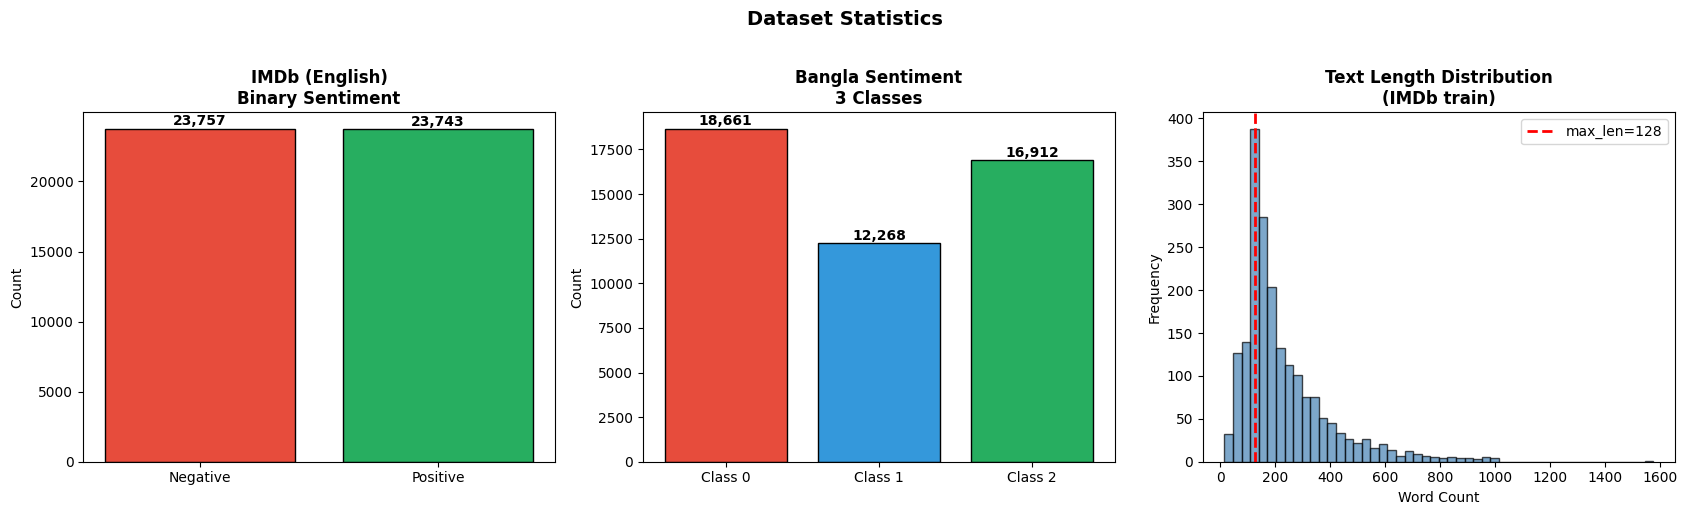

Figure 1 saved


In [11]:
# ============================================================
# CELL 8: DATASET STATISTICS FIGURE (IEEE Figure 1)
# ============================================================

def get_bangla_dataset():
    for var_name in ["BANGLA_RAW", "BANGLA_DATA", "bangla_data", "bangla_ds", "bangla_tok_raw"]:
        if var_name in globals() and globals()[var_name] is not None:
            return globals()[var_name], var_name
    return None, None

def get_label_names_from_dataset(ds, split="train", label_col="label"):
    try:
        feat = ds[split].features[label_col]
        if hasattr(feat, "names") and feat.names is not None:
            return feat.names
    except Exception:
        pass
    return None

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Dataset Statistics", fontsize=14, fontweight="bold", y=1.02)

# ─── Plot 1: IMDb label distribution ───
en_labels = list(IMDB_DATA["train"]["label"]) + list(IMDB_DATA["test"]["label"])
counts_en = [en_labels.count(0), en_labels.count(1)]
bars1 = axes[0].bar(
    ["Negative", "Positive"],
    counts_en,
    color=["#e74c3c", "#27ae60"],
    edgecolor="black"
)
axes[0].set_title("IMDb (English)\nBinary Sentiment", fontweight="bold")
axes[0].set_ylabel("Count")
for b, v in zip(bars1, counts_en):
    axes[0].text(
        b.get_x() + b.get_width() / 2,
        v + max(counts_en) * 0.01,
        f"{v:,}",
        ha="center",
        fontweight="bold"
    )

# ─── Plot 2: Bangla label distribution ───
bangla_source, bangla_var_name = get_bangla_dataset()

if bangla_loaded and bangla_source is not None and "train" in bangla_source:
    bn_labels = list(bangla_source["train"]["label"])
    bn_counter = Counter(bn_labels)
    classes_bn = sorted(bn_counter.keys())

    label_names = get_label_names_from_dataset(bangla_source, split="train", label_col="label")
    if label_names is not None:
        names_bn = [label_names[c] if c < len(label_names) else f"Class {c}" for c in classes_bn]
    else:
        names_bn = [f"Class {c}" for c in classes_bn]

    vals_bn = [bn_counter[c] for c in classes_bn]
    colors_bn = ["#e74c3c", "#3498db", "#27ae60"][:len(classes_bn)]

    bars2 = axes[1].bar(names_bn, vals_bn, color=colors_bn, edgecolor="black")
    axes[1].set_title(f"Bangla Sentiment\n{len(classes_bn)} Classes", fontweight="bold")
    axes[1].set_ylabel("Count")

    for b, v in zip(bars2, vals_bn):
        axes[1].text(
            b.get_x() + b.get_width() / 2,
            v + max(vals_bn) * 0.01,
            f"{v:,}",
            ha="center",
            fontweight="bold"
        )

    print(f"Using Bangla dataset variable for plot: {bangla_var_name}")
else:
    axes[1].text(
        0.5, 0.5, "Bangla data\nnot loaded",
        ha="center", va="center",
        transform=axes[1].transAxes, fontsize=14
    )
    axes[1].set_title("Bangla Sentiment", fontweight="bold")

# ─── Plot 3: Text length histogram (IMDb) ───
lengths = [len(str(t).split()) for t in IMDB_DATA["train"]["text"][:2000]]
axes[2].hist(lengths, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
axes[2].axvline(
    CFG["max_len"],
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"max_len={CFG['max_len']}"
)
axes[2].set_title("Text Length Distribution\n(IMDb train)", fontweight="bold")
axes[2].set_xlabel("Word Count")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/fig1_dataset_stats.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure 1 saved")


In [12]:
# ============================================================
# CELL 9: UNIFIED TRAINING FUNCTION (ALL 4 METHODS)
# ============================================================

def to_plain_hf(ds):
    if ds is None:
        return None
    try:
        return ds.with_format(None)
    except Exception:
        try:
            ds.set_format(type=None)
            return ds
        except Exception:
            return ds

def prepare_for_trainer(ds):
    ds = to_plain_hf(ds)

    keep_cols = [c for c in ["input_ids", "attention_mask", "token_type_ids", "label", "labels"] if c in ds.column_names]
    drop_cols = [c for c in ds.column_names if c not in keep_cols]

    if drop_cols:
        ds = ds.remove_columns(drop_cols)

    if "label" in ds.column_names and "labels" not in ds.column_names:
        ds = ds.rename_column("label", "labels")

    return ds

def validate_label_range(ds, num_labels, ds_name):
    label_col = "labels" if "labels" in ds.column_names else "label"
    labels = [int(x) for x in ds[label_col]]
    uniq = sorted(set(labels))
    print(f"  {ds_name} unique labels: {uniq}")

    if not uniq:
        raise ValueError(f"{ds_name}: empty labels")
    if min(uniq) < 0:
        raise ValueError(f"{ds_name}: negative label found -> {uniq}")
    if max(uniq) >= num_labels:
        raise ValueError(f"{ds_name}: label out of range. unique={uniq}, num_labels={num_labels}")

def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    pct = 100.0 * trainable / total
    return trainable, total, pct

def compute_metrics_safe(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "weighted_f1": f1_score(labels, preds, average="weighted", zero_division=0),
    }

def method_pretty_name(method):
    return {
        "finetune": "Full Fine-Tuning",
        "soft_prompt": "Soft Prompt Tuning",
        "prefix": "Prefix Tuning",
        "p_tuning_v2": "P-Tuning v2",
    }[method]

def build_peft_config_safely(config_cls, kwargs):
    temp_kwargs = dict(kwargs)

    while True:
        try:
            return config_cls(**temp_kwargs)
        except TypeError as e:
            msg = str(e)
            print(f"  PEFT config fallback for {config_cls.__name__}: {msg}")

            if "unexpected keyword argument" in msg:
                bad_key = msg.split("'")[1]
                if bad_key in temp_kwargs:
                    temp_kwargs.pop(bad_key)
                    continue

            raise e

def unfreeze_classifier_head(model):
    for name, param in model.named_parameters():
        if (
            "classifier" in name
            or ".score" in name
            or "score." in name
            or "classification_head" in name
        ):
            param.requires_grad = True

def build_model_for_method(method, num_labels, num_virtual_tokens):
    base_model = AutoModelForSequenceClassification.from_pretrained(
        CFG["model_name"],
        num_labels=num_labels,
        ignore_mismatched_sizes=True
    )

    if method == "finetune":
        return base_model

    common_kwargs = {
        "task_type": TaskType.SEQ_CLS,
        "inference_mode": False,
        "token_dim": base_model.config.hidden_size,
        "num_transformer_submodules": 1,
        "num_attention_heads": base_model.config.num_attention_heads,
        "num_layers": base_model.config.num_hidden_layers,
    }

    if method == "soft_prompt":
        peft_config = build_peft_config_safely(
            PromptTuningConfig,
            {
                **common_kwargs,
                "prompt_tuning_init": PromptTuningInit.RANDOM,
                "num_virtual_tokens": num_virtual_tokens,
            }
        )
        model = get_peft_model(base_model, peft_config)
        unfreeze_classifier_head(model)
        return model

    if method == "prefix":
        peft_config = build_peft_config_safely(
            PrefixTuningConfig,
            {
                **common_kwargs,
                "num_virtual_tokens": num_virtual_tokens,
                "prefix_projection": True,
                "encoder_hidden_size": 128,
            }
        )
        model = get_peft_model(base_model, peft_config)
        unfreeze_classifier_head(model)
        return model

    if method == "p_tuning_v2":
        peft_config = build_peft_config_safely(
            PromptEncoderConfig,
            {
                **common_kwargs,
                "num_virtual_tokens": num_virtual_tokens,
                "encoder_hidden_size": 128,
                "encoder_reparameterization_type": "MLP",
            }
        )
        model = get_peft_model(base_model, peft_config)
        unfreeze_classifier_head(model)
        return model

    raise ValueError(f"Unknown method: {method}")

def run_experiment(method, train_data, eval_data, num_labels,
                   run_name, num_epochs=None, num_virtual_tokens=None):
    clear_gpu()

    train_data = prepare_for_trainer(train_data)
    eval_data = prepare_for_trainer(eval_data)

    validate_label_range(train_data, num_labels, f"{run_name} train")
    validate_label_range(eval_data, num_labels, f"{run_name} eval")

    if num_epochs is None:
        num_epochs = CFG["epochs_ft"] if method == "finetune" else CFG["epochs_pt"]
    if num_virtual_tokens is None:
        num_virtual_tokens = CFG["num_virtual_tokens"]

    lr = CFG["lr_ft"] if method == "finetune" else CFG["lr_pt"]

    print(f"\n{'━'*60}")
    print(f"  {method_pretty_name(method)} | {run_name}")
    print(f"  Train: {len(train_data)} | Eval: {len(eval_data)} | Labels: {num_labels}")
    print(f"  Epochs: {num_epochs} | LR: {lr} | VT: {num_virtual_tokens}")
    print(f"{'━'*60}")

    model = build_model_for_method(method, num_labels, num_virtual_tokens)
    trainable, total, pct = count_params(model)
    print(f"  Params: {trainable:,} trainable / {total:,} total ({pct:.4f}%)")

    current_tokenizer = globals().get("tokenizer", None)
    if current_tokenizer is None:
        current_tokenizer = AutoTokenizer.from_pretrained(CFG["model_name"])

    data_collator = DataCollatorWithPadding(
        tokenizer=current_tokenizer,
        pad_to_multiple_of=8 if torch.cuda.is_available() else None
    )

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = f"{CFG['output_dir']}/{run_name}_{timestamp}"

    training_args = TrainingArguments(
        output_dir=out_dir,
        overwrite_output_dir=True,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=CFG["batch_size"],
        per_device_eval_batch_size=CFG["batch_size"] * 2,
        gradient_accumulation_steps=CFG["grad_accum"],
        learning_rate=lr,
        warmup_ratio=CFG["warmup"],
        weight_decay=CFG["weight_decay"] if method == "finetune" else 0.0,
        evaluation_strategy="epoch",
        save_strategy="no",
        load_best_model_at_end=False,
        fp16=torch.cuda.is_available(),
        logging_steps=max(1, len(train_data) // max(1, (CFG["batch_size"] * 4))),
        report_to="none",
        seed=SEED,
        dataloader_num_workers=0,
        remove_unused_columns=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_data,
        eval_dataset=eval_data,
        tokenizer=current_tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics_safe,
    )

    start = time.time()
    trainer.train()
    train_time = (time.time() - start) / 60.0

    metrics = trainer.evaluate(eval_dataset=eval_data)
    preds_output = trainer.predict(eval_data)
    preds = np.argmax(preds_output.predictions, axis=-1)
    true_labels = preds_output.label_ids

    result = {
        "method": method_pretty_name(method),
        "method_key": method,
        "run_name": run_name,
        "num_labels": num_labels,
        "n_train": len(train_data),
        "n_eval": len(eval_data),
        "accuracy": metrics.get("eval_accuracy", 0.0),
        "macro_f1": metrics.get("eval_macro_f1", 0.0),
        "weighted_f1": metrics.get("eval_weighted_f1", 0.0),
        "trainable_params": trainable,
        "total_params": total,
        "param_pct": round(pct, 4),
        "train_time_min": round(train_time, 2),
        "num_virtual_tokens": num_virtual_tokens if method != "finetune" else 0,
        "num_epochs": num_epochs,
        "predictions": preds.tolist(),
        "true_labels": true_labels.tolist(),
    }

    if "save_result" in globals():
        try:
            save_result({k: v for k, v in result.items() if k not in ["predictions", "true_labels"]})
        except Exception as e:
            print(f"  save_result skipped: {e}")

    print(
        f"\n  DONE | Acc: {result['accuracy']:.4f} | "
        f"F1: {result['macro_f1']:.4f} | "
        f"Time: {result['train_time_min']:.1f}min | "
        f"Params: {pct:.4f}%"
    )

    del trainer
    clear_gpu()
    return result, model

print(" Unified training function ready")


 Unified training function ready


In [13]:
# ============================================================
# CELL 10: ★★★ RUN ALL MAIN EXPERIMENTS ★★★
# ============================================================

METHODS = ["finetune", "soft_prompt", "prefix", "p_tuning_v2"]
MAIN_RESULTS = {}

def infer_num_labels_from_datasets(*datasets):
    uniq = set()
    for ds in datasets:
        if ds is None:
            continue
        label_col = "labels" if "labels" in ds.column_names else "label"
        uniq.update(int(x) for x in ds[label_col])

    uniq = sorted(uniq)
    if not uniq:
        raise ValueError("No labels found to infer num_labels.")
    return len(uniq), uniq

print("\n" + "=" * 60)
print("  ENGLISH EXPERIMENTS (IMDb)")
print("=" * 60)

if CFG["TEST_MODE"] and 1000 in imdb_subsets:
    en_train = imdb_subsets[1000]
else:
    en_train = imdb_subsets["full"]

en_eval = imdb_eval
NUM_CLASSES_EN, EN_LABEL_SET = infer_num_labels_from_datasets(en_train, en_eval)
print(f"English label set: {EN_LABEL_SET} | NUM_CLASSES_EN = {NUM_CLASSES_EN}")

for method in METHODS:
    model = None
    run_name = f"EN_{method}"
    try:
        result, model = run_experiment(
            method=method,
            train_data=en_train,
            eval_data=en_eval,
            num_labels=NUM_CLASSES_EN,
            run_name=run_name,
        )
        MAIN_RESULTS[run_name] = result

        if method in ["finetune", "soft_prompt"]:
            model_path = f"{CFG['save_dir']}/{run_name}"
            if hasattr(model, "save_pretrained"):
                model.save_pretrained(model_path)
                print(f"  Model saved: {model_path}")
    except Exception as e:
        print(f"   EN {method} failed: {e}")
    finally:
        if model is not None:
            del model
        clear_gpu()

if bangla_tok is not None and bangla_eval is not None:
    print("\n" + "=" * 60)
    print("  BANGLA EXPERIMENTS")
    print("=" * 60)

    if CFG["TEST_MODE"] and 1000 in bangla_subsets:
        bn_train = bangla_subsets[1000]
    else:
        bn_train = bangla_subsets["full"]

    bn_eval = bangla_eval
    NUM_CLASSES_BN, BN_LABEL_SET = infer_num_labels_from_datasets(bn_train, bn_eval)
    print(f"Bangla label set: {BN_LABEL_SET} | NUM_CLASSES_BN = {NUM_CLASSES_BN}")

    for method in METHODS:
        model = None
        run_name = f"BN_{method}"
        try:
            result, model = run_experiment(
                method=method,
                train_data=bn_train,
                eval_data=bn_eval,
                num_labels=NUM_CLASSES_BN,
                run_name=run_name,
            )
            MAIN_RESULTS[run_name] = result
        except Exception as e:
            print(f"   BN {method} failed: {e}")
        finally:
            if model is not None:
                del model
            clear_gpu()

print("\n" + "=" * 70)
print("  MAIN RESULTS SUMMARY")
print("=" * 70)
print(f"{'Run':<25} {'Method':<22} {'Acc':<8} {'F1':<8} {'Params%':<10} {'Time'}")
print("-" * 70)

for name, r in MAIN_RESULTS.items():
    print(
        f"{name:<25} {r['method']:<22} {r['accuracy']:<8.4f} "
        f"{r['macro_f1']:<8.4f} {r['param_pct']:<10.4f} {r['train_time_min']:.1f}min"
    )

print("=" * 70)

MAIN_RESULTS_DF = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["predictions", "true_labels"]}
    for r in MAIN_RESULTS.values()
])
MAIN_RESULTS_DF.to_csv(f"{CFG['output_dir']}/main_results.csv", index=False)
print("Main results saved")



  ENGLISH EXPERIMENTS (IMDb)
English label set: [0, 1] | NUM_CLASSES_EN = 2
  EN_finetune train unique labels: [0, 1]
  EN_finetune eval unique labels: [0, 1]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Full Fine-Tuning | EN_finetune
  Train: 22500 | Eval: 25000 | Labels: 2
  Epochs: 5 | LR: 2e-05 | VT: 50
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Params: 278,045,186 trainable / 278,045,186 total (100.0000%)


 20%|██        | 1406/7030 [14:08<47:01,  1.99it/s]  

{'loss': 0.439, 'grad_norm': 15.012727737426758, 'learning_rate': 1.7793583056740954e-05, 'epoch': 1.0}


...

{'loss': 1.084, 'grad_norm': 1.0909435749053955, 'learning_rate': 1.3935340022296542e-07, 'epoch': 12.0}



100%|██████████| 35880/35880 [2:44:45<00:00,  3.63it/s]


{'eval_loss': 1.0705417394638062, 'eval_accuracy': 0.4460388279271675, 'eval_macro_f1': 0.20563709139426287, 'eval_weighted_f1': 0.27516638167154645, 'eval_runtime': 35.0388, 'eval_samples_per_second': 236.68, 'eval_steps_per_second': 29.596, 'epoch': 12.0}
{'train_runtime': 9885.0822, 'train_samples_per_second': 58.077, 'train_steps_per_second': 3.63, 'train_loss': 1.0875616951796787, 'epoch': 12.0}


100%|██████████| 1037/1037 [00:34<00:00, 30.06it/s]



  DONE | Acc: 0.4460 | F1: 0.2056 | Time: 164.8min | Params: 0.5157%

  MAIN RESULTS SUMMARY
Run                       Method                 Acc      F1       Params%    Time
----------------------------------------------------------------------
EN_finetune               Full Fine-Tuning       0.8841   0.8841   100.0000   69.4min
EN_soft_prompt            Soft Prompt Tuning     0.6747   0.6741   0.4387     96.4min
EN_prefix                 Prefix Tuning          0.8810   0.8810   1.3156     99.7min
EN_p_tuning_v2            P-Tuning v2            0.8196   0.8196   0.5151     106.2min
BN_finetune               Full Fine-Tuning       0.6164   0.5759   100.0000   132.2min
BN_soft_prompt            Soft Prompt Tuning     0.4744   0.3838   0.4393     178.0min
BN_prefix                 Prefix Tuning          0.4474   0.2235   1.3161     166.0min
BN_p_tuning_v2            P-Tuning v2            0.4460   0.2056   0.5157     164.8min
Main results saved


In [14]:
# ============================================================
# CELL 11: DATA EFFICIENCY EXPERIMENT (Main Contribution)
# ============================================================

DATA_EFF_RESULTS = []

def get_subset_safe(subsets_dict, n):
    if n == "full":
        return subsets_dict["full"]
    return subsets_dict[n]

print("=" * 60)
print("  DATA EFFICIENCY EXPERIMENT")
print("=" * 60)

for n in CFG["sample_sizes"]:
    if n not in imdb_subsets:
        continue

    train_sub = get_subset_safe(imdb_subsets, n)
    n_show = len(train_sub)
    print(f"\n{'─'*35} IMDb N = {n_show} {'─'*35}")

    for method in METHODS:
        model = None
        run_name = f"eff_EN_{method}_n{n}"
        try:
            ep = min(5, CFG["epochs_pt"]) if method != "finetune" else min(3, CFG["epochs_ft"])
            result, model = run_experiment(
                method=method,
                train_data=train_sub,
                eval_data=imdb_eval,
                num_labels=NUM_CLASSES_EN,
                run_name=run_name,
                num_epochs=ep,
            )
            result["dataset"] = "IMDb"
            result["sample_size"] = n_show
            DATA_EFF_RESULTS.append(result)
        except Exception as e:
            print(f"   Error: {method} n={n}: {e}")
        finally:
            if model is not None:
                del model
            clear_gpu()

if bangla_tok is not None and bangla_eval is not None:
    for n in CFG["sample_sizes"]:
        if n not in bangla_subsets:
            continue

        train_sub = get_subset_safe(bangla_subsets, n)
        n_show = len(train_sub)
        print(f"\n{'─'*34} Bangla N = {n_show} {'─'*34}")

        for method in METHODS:
            model = None
            run_name = f"eff_BN_{method}_n{n}"
            try:
                ep = min(5, CFG["epochs_pt"]) if method != "finetune" else min(3, CFG["epochs_ft"])
                result, model = run_experiment(
                    method=method,
                    train_data=train_sub,
                    eval_data=bangla_eval,
                    num_labels=NUM_CLASSES_BN,
                    run_name=run_name,
                    num_epochs=ep,
                )
                result["dataset"] = "Bangla"
                result["sample_size"] = n_show
                DATA_EFF_RESULTS.append(result)
            except Exception as e:
                print(f"   Error: {method} n={n}: {e}")
            finally:
                if model is not None:
                    del model
                clear_gpu()

df_eff = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["predictions", "true_labels"]}
    for r in DATA_EFF_RESULTS
])
df_eff.to_csv(f"{CFG['output_dir']}/data_efficiency_results.csv", index=False)
print(f"\n Data efficiency results saved ({len(DATA_EFF_RESULTS)} runs)")


  DATA EFFICIENCY EXPERIMENT

─────────────────────────────────── IMDb N = 100 ───────────────────────────────────
  eff_EN_finetune_n100 train unique labels: [0, 1]
  eff_EN_finetune_n100 eval unique labels: [0, 1]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Full Fine-Tuning | eff_EN_finetune_n100
  Train: 100 | Eval: 25000 | Labels: 2
  Epochs: 3 | LR: 2e-05 | VT: 50
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Params: 278,045,186 trainable / 278,045,186 total (100.0000%)


 33%|███▎      | 6/18 [00:03<00:05,  2.02it/s]

{'loss': 0.712, 'grad_norm': 4.755209445953369, 'learning_rate': 1.5000000000000002e-05, 'epoch': 0.96}


...

{'loss': 1.0895, 'grad_norm': 2.190776824951172, 'learning_rate': 1.0683760683760682e-06, 'epoch': 4.99}



100%|██████████| 1560/1560 [11:17<00:00,  2.30it/s]


{'eval_loss': 1.0691921710968018, 'eval_accuracy': 0.4460388279271675, 'eval_macro_f1': 0.20563709139426287, 'eval_weighted_f1': 0.27516638167154645, 'eval_runtime': 39.8462, 'eval_samples_per_second': 208.125, 'eval_steps_per_second': 26.025, 'epoch': 4.99}
{'train_runtime': 677.5111, 'train_samples_per_second': 36.9, 'train_steps_per_second': 2.303, 'train_loss': 1.0964016645382613, 'epoch': 4.99}


100%|██████████| 1037/1037 [00:39<00:00, 26.06it/s]



  DONE | Acc: 0.4460 | F1: 0.2056 | Time: 11.3min | Params: 0.5157%

 Data efficiency results saved (32 runs)


In [15]:
# ============================================================
# CELL 12: ABLATION STUDY — PROMPT LENGTH
# ============================================================

ABLATION_RESULTS = []

print("=" * 60)
print("  ABLATION: PROMPT LENGTH")
print("=" * 60)

abl_train = imdb_subsets[1000] if 1000 in imdb_subsets else imdb_subsets["full"]
abl_eval = imdb_eval

for plen in CFG["ablation_lengths"]:
    model = None
    print(f"\n>> Prompt Length = {plen}")
    run_name = f"abl_spt_len{plen}"
    try:
        result, model = run_experiment(
            method="soft_prompt",
            train_data=abl_train,
            eval_data=abl_eval,
            num_labels=NUM_CLASSES_EN,
            run_name=run_name,
            num_epochs=min(5, CFG["epochs_pt"]),
            num_virtual_tokens=plen,
        )
        result["prompt_length"] = plen
        ABLATION_RESULTS.append(result)
    except Exception as e:
        print(f"   Error at plen={plen}: {e}")
    finally:
        if model is not None:
            del model
        clear_gpu()

df_abl = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["predictions", "true_labels"]}
    for r in ABLATION_RESULTS
])
df_abl.to_csv(f"{CFG['output_dir']}/ablation_prompt_length.csv", index=False)
print(f"\n Ablation results saved ({len(ABLATION_RESULTS)} runs)")


  ABLATION: PROMPT LENGTH

>> Prompt Length = 10
  abl_spt_len10 train unique labels: [0, 1]
  abl_spt_len10 eval unique labels: [0, 1]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Soft Prompt Tuning | abl_spt_len10
  Train: 1000 | Eval: 25000 | Labels: 2
  Epochs: 5 | LR: 0.0003 | VT: 10
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /xlm-roberta-base/resolve/main/config.json (Caused by ConnectTimeoutError(<HTTPSConnection(host='huggingface.co', port=443) at 0x11ea54f5c10>, 'Connection to huggingface.co timed out. (connect timeout=10)'))"), '(Request ID: 7a622555-6a7c-4798-86a4-91dd8f05b283)')' thrown while requesting HEAD https://huggingface.co/xlm-roberta-base/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /xlm-roberta-base/resolve/main/config.json (Caused by ConnectTimeoutError(<HTTPSConnection(host='huggingface.co', port=443) at 0x11ea54f5690>, 'Connection to huggingface.co timed out. (connect timeout=10)'))"), '(Request ID: f5b06dfa-957f-4d81-b552-c147857e806c)')' thrown while requesting HEAD https://huggingface.co/xlm-roberta-base/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(MaxRetryError("HTT

  Params: 1,191,940 trainable / 278,644,996 total (0.4278%)


 20%|██        | 62/310 [00:15<01:00,  4.13it/s]

{'loss': 0.7033, 'grad_norm': 1.8189046382904053, 'learning_rate': 0.00027096774193548386, 'epoch': 0.99}


...

{'loss': 0.6869, 'grad_norm': 3.888239860534668, 'learning_rate': 5.376344086021505e-06, 'epoch': 4.96}



100%|██████████| 310/310 [12:25<00:00,  2.40s/it]  


{'eval_loss': 0.6810211539268494, 'eval_accuracy': 0.60344, 'eval_macro_f1': 0.6034098439190758, 'eval_weighted_f1': 0.6034098439190758, 'eval_runtime': 128.3232, 'eval_samples_per_second': 194.821, 'eval_steps_per_second': 24.353, 'epoch': 4.96}
{'train_runtime': 745.4103, 'train_samples_per_second': 6.708, 'train_steps_per_second': 0.416, 'train_loss': 0.6943018513341104, 'epoch': 4.96}


100%|██████████| 3125/3125 [02:06<00:00, 24.74it/s]



  DONE | Acc: 0.6034 | F1: 0.6034 | Time: 12.4min | Params: 0.4525%

 Ablation results saved (4 runs)


In [16]:
# ============================================================
# CELL 13: CROSS-LINGUAL TRANSFER (EN → BN)  — BUG FIXED
# ============================================================

CROSSLINGUAL_RESULTS = []

def make_binary_bangla_eval(ds):
    """
    Bangla has 3 classes (0=Neg, 1=Neutral, 2=Pos).
    EN model has 2 classes (0=Neg, 1=Pos).
    Keep only Neg(0) and Pos(2) samples, remap → 0 and 1.
    """
    ds = to_plain_hf(ds)
    label_col = "labels" if "labels" in ds.column_names else "label"

    labels_list = [int(x) for x in ds[label_col]]
    keep_indices = [i for i, y in enumerate(labels_list) if y in [0, 2]]

    if len(keep_indices) == 0:
        raise ValueError("No Negative/Positive Bangla examples found.")

    ds_bin = ds.select(keep_indices)

    # Remap: 0→0 (Negative), 2→1 (Positive)
    def remap(example):
        lc = "labels" if "labels" in example else "label"
        example[lc] = 0 if int(example[lc]) == 0 else 1
        return example

    ds_bin = ds_bin.map(remap, desc="Remapping binary labels")
    return prepare_for_trainer(ds_bin)   # renames label→labels, sets torch format


def predict_zero_shot(model, dataset, batch_size=32):
    """
    Run inference on dataset with a trained model.
    FIX: explicit tensor conversion + no labels passed to model.
    """
    # Ensure torch format with correct columns only
    ds = to_plain_hf(dataset)
    keep = [c for c in ["input_ids", "attention_mask", "token_type_ids", "labels"]
            if c in ds.column_names]
    drop = [c for c in ds.column_names if c not in keep]
    if drop:
        ds = ds.remove_columns(drop)
    ds.set_format("torch")                # ← FIX: explicitly set torch format here

    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    all_preds, all_true = [], []
    model.eval()
    model.to(device)

    with torch.no_grad():
        for batch in tqdm(loader, desc="  Zero-shot BN eval", leave=False):

            # ── FIX: safe tensor extraction ──
            input_ids      = batch["input_ids"]
            attention_mask = batch["attention_mask"]
            true_labels    = batch["labels"]

            # Convert to long tensors (fixes "integer tensor" error)
            if not isinstance(input_ids, torch.Tensor):
                input_ids = torch.tensor(input_ids, dtype=torch.long)
            if not isinstance(attention_mask, torch.Tensor):
                attention_mask = torch.tensor(attention_mask, dtype=torch.long)
            if not isinstance(true_labels, torch.Tensor):
                true_labels = torch.tensor(true_labels, dtype=torch.long)

            input_ids      = input_ids.long().to(device)
            attention_mask = attention_mask.long().to(device)

            # ── FIX: pass ONLY input_ids + attention_mask (no labels to model) ──
            try:
                out = model(input_ids=input_ids, attention_mask=attention_mask)
            except Exception as e:
                print(f"    ⚠️ Batch inference error: {e} — skipping batch")
                continue

            preds = torch.argmax(out.logits, dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_true.extend(true_labels.cpu().tolist())

    return all_preds, all_true


# ── Run Cross-Lingual Experiments ──
if bangla_tok is not None and bangla_eval is not None:
    print("=" * 60)
    print("  CROSS-LINGUAL TRANSFER: EN → BN")
    print("=" * 60)

    cl_train = imdb_subsets["full"] if not CFG["TEST_MODE"] else imdb_subsets.get(1000, imdb_subsets["full"])

    try:
        binary_bn_eval = make_binary_bangla_eval(bangla_eval)
        print(f"  Binary Bangla eval size: {len(binary_bn_eval)}")
        print(f"  Label dist: {Counter(int(x) for x in binary_bn_eval['labels'])}")
    except Exception as e:
        print(f"  ❌ Binary Bangla eval creation failed: {e}")
        binary_bn_eval = None

    if binary_bn_eval is not None:
        for method in METHODS:
            model = None
            run_name = f"CL_{method}_EN2BN"
            print(f"\n  ── {method_pretty_name(method)} ──")
            try:
                # Step 1: Train on English
                result, model = run_experiment(
                    method=method,
                    train_data=cl_train,
                    eval_data=imdb_eval,
                    num_labels=2,
                    run_name=run_name,
                )
                en_f1  = result["macro_f1"]
                en_acc = result["accuracy"]

                # Step 2: Zero-shot evaluate on Bangla (binary)
                bn_preds, bn_true = predict_zero_shot(model, binary_bn_eval)

                bn_acc = accuracy_score(bn_true, bn_preds)
                bn_f1  = f1_score(bn_true, bn_preds, average="macro", zero_division=0)
                gap    = round(en_f1 - bn_f1, 4)

                cl_result = {
                    "method":       result["method"],
                    "en_accuracy":  round(en_acc, 4),
                    "en_macro_f1":  round(en_f1,  4),
                    "bn_accuracy":  round(bn_acc, 4),
                    "bn_macro_f1":  round(bn_f1,  4),
                    "transfer_gap": gap,
                }
                CROSSLINGUAL_RESULTS.append(cl_result)
                print(f"  ✅ EN F1={en_f1:.4f} → BN F1={bn_f1:.4f} | Gap={gap:.4f}")

            except Exception as e:
                import traceback
                print(f"  ❌ {method} failed: {e}")
                traceback.print_exc()
            finally:
                if model is not None:
                    del model
                clear_gpu()

        if CROSSLINGUAL_RESULTS:
            df_cl = pd.DataFrame(CROSSLINGUAL_RESULTS)
            df_cl.to_csv(f"{CFG['output_dir']}/crosslingual_results.csv", index=False)
            print(f"\n  ✅ Cross-lingual results saved ({len(CROSSLINGUAL_RESULTS)} methods)")
            print(df_cl[["method","en_macro_f1","bn_macro_f1","transfer_gap"]].to_string(index=False))
        else:
            print("  ⚠️  No cross-lingual results collected.")
else:
    print("⏭️  Cross-lingual skipped — Bangla data not loaded.")

  CROSS-LINGUAL TRANSFER: EN → BN


Remapping binary labels: 100%|██████████| 6362/6362 [00:00<00:00, 7243.02 examples/s]


  Binary Bangla eval size: 6362
  Label dist: Counter({0: 3699, 1: 2663})

  ── Full Fine-Tuning ──
  CL_finetune_EN2BN train unique labels: [0, 1]
  CL_finetune_EN2BN eval unique labels: [0, 1]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Full Fine-Tuning | CL_finetune_EN2BN
  Train: 22500 | Eval: 25000 | Labels: 2
  Epochs: 5 | LR: 2e-05 | VT: 50
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Params: 278,045,186 trainable / 278,045,186 total (100.0000%)


...


100%|██████████| 16872/16872 [1:50:31<00:00,  2.54it/s]


{'eval_loss': 0.36163511872291565, 'eval_accuracy': 0.84208, 'eval_macro_f1': 0.8420726974415297, 'eval_weighted_f1': 0.8420726974415296, 'eval_runtime': 117.7139, 'eval_samples_per_second': 212.379, 'eval_steps_per_second': 26.547, 'epoch': 12.0}
{'train_runtime': 6631.9029, 'train_samples_per_second': 40.712, 'train_steps_per_second': 2.544, 'train_loss': 0.4592506007144326, 'epoch': 12.0}


100%|██████████| 3125/3125 [01:56<00:00, 26.89it/s]



  DONE | Acc: 0.8421 | F1: 0.8421 | Time: 110.5min | Params: 0.5151%


  ✅ EN F1=0.8421 → BN F1=0.5319 | Gap=0.3102

  ✅ Cross-lingual results saved (4 methods)
            method  en_macro_f1  bn_macro_f1  transfer_gap
  Full Fine-Tuning       0.8837       0.5953        0.2884
Soft Prompt Tuning       0.6471       0.4804        0.1667
     Prefix Tuning       0.8796       0.5393        0.3404
       P-Tuning v2       0.8421       0.5319        0.3102


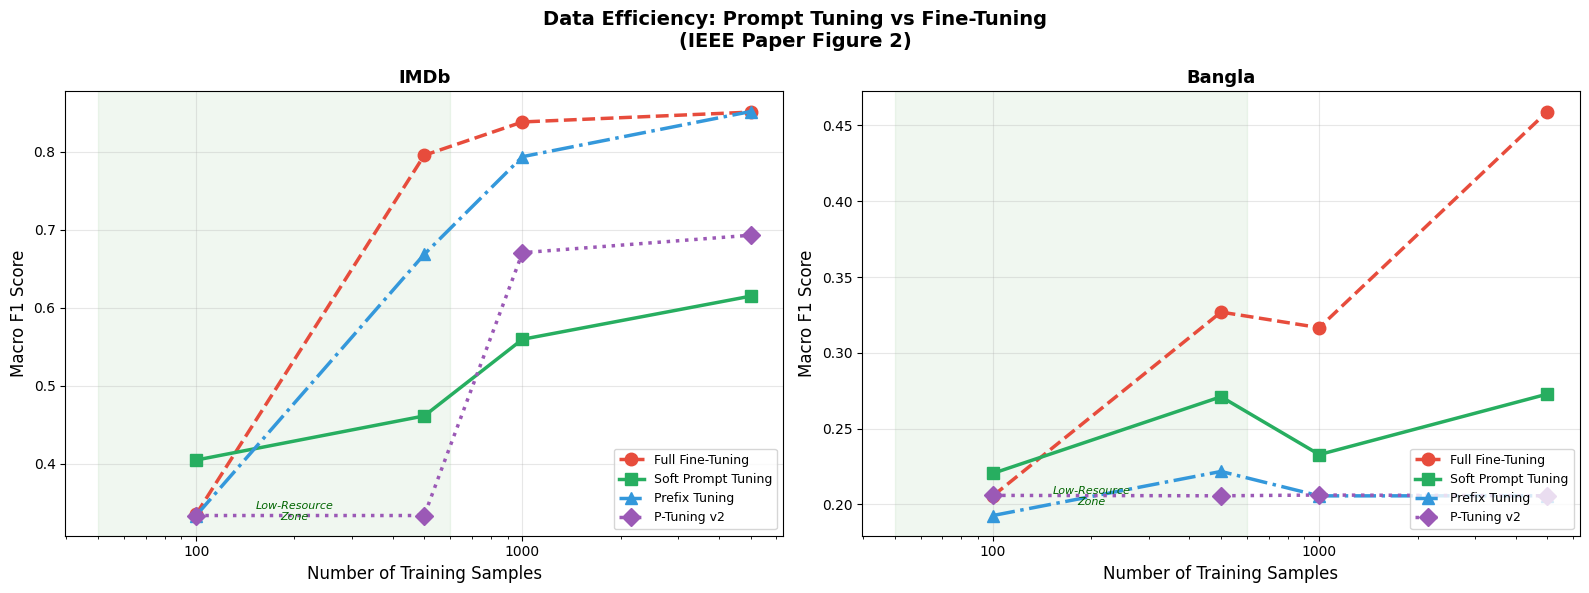

 Figure 2 saved: fig2_data_efficiency.png


In [17]:
# ============================================================
# CELL 14: DATA EFFICIENCY FIGURE (IEEE Paper Figure 2)
# ============================================================

df_eff = pd.read_csv(f"{CFG['output_dir']}/data_efficiency_results.csv")

method_display = {
    'Full Fine-Tuning': {'color': '#e74c3c', 'marker': 'o', 'ls': '--'},
    'Soft Prompt Tuning': {'color': '#27ae60', 'marker': 's', 'ls': '-'},
    'Prefix Tuning': {'color': '#3498db', 'marker': '^', 'ls': '-.'},
    'P-Tuning v2': {'color': '#9b59b6', 'marker': 'D', 'ls': ':'},
}

# Determine datasets present
datasets_present = df_eff['dataset'].unique() if 'dataset' in df_eff.columns else ['IMDb']
n_plots = len(datasets_present)

fig, axes = plt.subplots(1, max(n_plots, 2), figsize=(8*max(n_plots, 2), 6))
if not isinstance(axes, np.ndarray):
    axes = [axes]
fig.suptitle('Data Efficiency: Prompt Tuning vs Fine-Tuning\n(IEEE Paper Figure 2)',
             fontsize=14, fontweight='bold')

for idx, dataset_name in enumerate(datasets_present):
    ax = axes[idx]
    df_sub = df_eff[df_eff['dataset'] == dataset_name] if 'dataset' in df_eff.columns else df_eff

    for method_name, style in method_display.items():
        df_m = df_sub[df_sub['method'] == method_name].sort_values('sample_size')
        if len(df_m) > 0:
            ax.plot(df_m['sample_size'], df_m['macro_f1'],
                    label=method_name, color=style['color'],
                    marker=style['marker'], linestyle=style['ls'],
                    linewidth=2.5, markersize=9)

    ax.set_xlabel('Number of Training Samples', fontsize=12)
    ax.set_ylabel('Macro F1 Score', fontsize=12)
    ax.set_title(f'{dataset_name}', fontweight='bold', fontsize=13)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

    # Highlight low-resource region
    ax.axvspan(50, 600, alpha=0.06, color='green')
    ax.text(200, ax.get_ylim()[0] + 0.02, 'Low-Resource\nZone',
            fontsize=8, color='darkgreen', fontstyle='italic', ha='center')

# Hide extra axes if only 1 dataset
for idx in range(len(datasets_present), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/fig2_data_efficiency.png", dpi=300, bbox_inches='tight')
plt.show()
print(" Figure 2 saved: fig2_data_efficiency.png")

In [ ]:
# ============================================================
# CELL 15: CROSS-LINGUAL TRANSFER FIGURE (IEEE Figure 3)
# ============================================================

if len(CROSSLINGUAL_RESULTS) > 0:
    df_cl = pd.DataFrame(CROSSLINGUAL_RESULTS)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Cross-Lingual Transfer: English → Bangla\n(IEEE Paper Figure 3)',
                 fontsize=14, fontweight='bold')

    x = np.arange(len(df_cl))
    w = 0.35

    # Left: EN vs BN F1
    b1 = axes[0].bar(x - w/2, df_cl['en_macro_f1'], w, label='English (Source)',
                     color='#3498db', edgecolor='black', alpha=0.85)
    b2 = axes[0].bar(x + w/2, df_cl['bn_macro_f1'], w, label='Bangla (Zero-shot)',
                     color='#e67e22', edgecolor='black', alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df_cl['method'], rotation=12, ha='right', fontsize=9)
    axes[0].set_ylabel('Macro F1', fontsize=12)
    axes[0].set_title('Source vs Transfer Performance', fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].set_ylim(0, 1.0)
    axes[0].grid(True, axis='y', alpha=0.3)
    for bar in b1:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f'{bar.get_height():.2f}', ha='center', fontsize=9)
    for bar in b2:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f'{bar.get_height():.2f}', ha='center', fontsize=9)

    # Right: Transfer Gap
    colors_gap = ['#e74c3c', '#27ae60', '#3498db', '#9b59b6'][:len(df_cl)]
    b3 = axes[1].bar(df_cl['method'], df_cl['transfer_gap'],
                     color=colors_gap, edgecolor='black', alpha=0.85)
    axes[1].set_ylabel('Transfer Gap (EN F1 − BN F1) ↓', fontsize=12)
    axes[1].set_title('Transfer Gap (Lower = Better)', fontweight='bold')
    axes[1].set_xticklabels(df_cl['method'], rotation=12, ha='right', fontsize=9)
    axes[1].grid(True, axis='y', alpha=0.3)
    for bar in b3:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                     f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/fig3_crosslingual.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(" Figure 3 saved")
else:
    print("⏭ No cross-lingual results to plot")

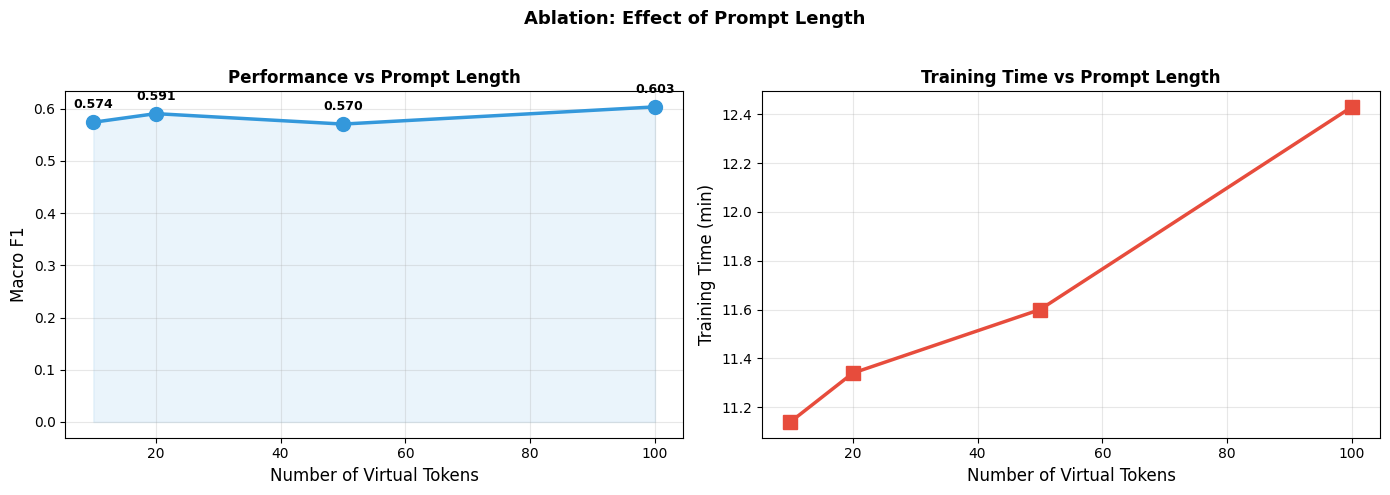

 Figure 4 saved


In [18]:
# ============================================================
# CELL 16: ABLATION FIGURE (IEEE Figure 4)
# ============================================================

if len(ABLATION_RESULTS) > 0:
    df_abl = pd.DataFrame([{k: v for k, v in r.items() if k not in ['predictions', 'true_labels']}
                           for r in ABLATION_RESULTS])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Ablation: Effect of Prompt Length\n',
                 fontweight='bold', fontsize=13)

    # Left: F1 vs prompt length
    axes[0].plot(df_abl['prompt_length'], df_abl['macro_f1'],
                 'o-', color='#3498db', linewidth=2.5, markersize=10)
    axes[0].fill_between(df_abl['prompt_length'], df_abl['macro_f1'],
                          alpha=0.1, color='#3498db')
    axes[0].set_xlabel('Number of Virtual Tokens', fontsize=12)
    axes[0].set_ylabel('Macro F1', fontsize=12)
    axes[0].set_title('Performance vs Prompt Length', fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    for _, row in df_abl.iterrows():
        axes[0].annotate(f"{row['macro_f1']:.3f}",
                         (row['prompt_length'], row['macro_f1']),
                         textcoords='offset points', xytext=(0, 10),
                         ha='center', fontsize=9, fontweight='bold')

    # Right: Time vs prompt length
    axes[1].plot(df_abl['prompt_length'], df_abl['train_time_min'],
                 's-', color='#e74c3c', linewidth=2.5, markersize=10)
    axes[1].set_xlabel('Number of Virtual Tokens', fontsize=12)
    axes[1].set_ylabel('Training Time (min)', fontsize=12)
    axes[1].set_title('Training Time vs Prompt Length', fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/fig4_ablation.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(" Figure 4 saved")
else:
    print("⏭ No ablation results")

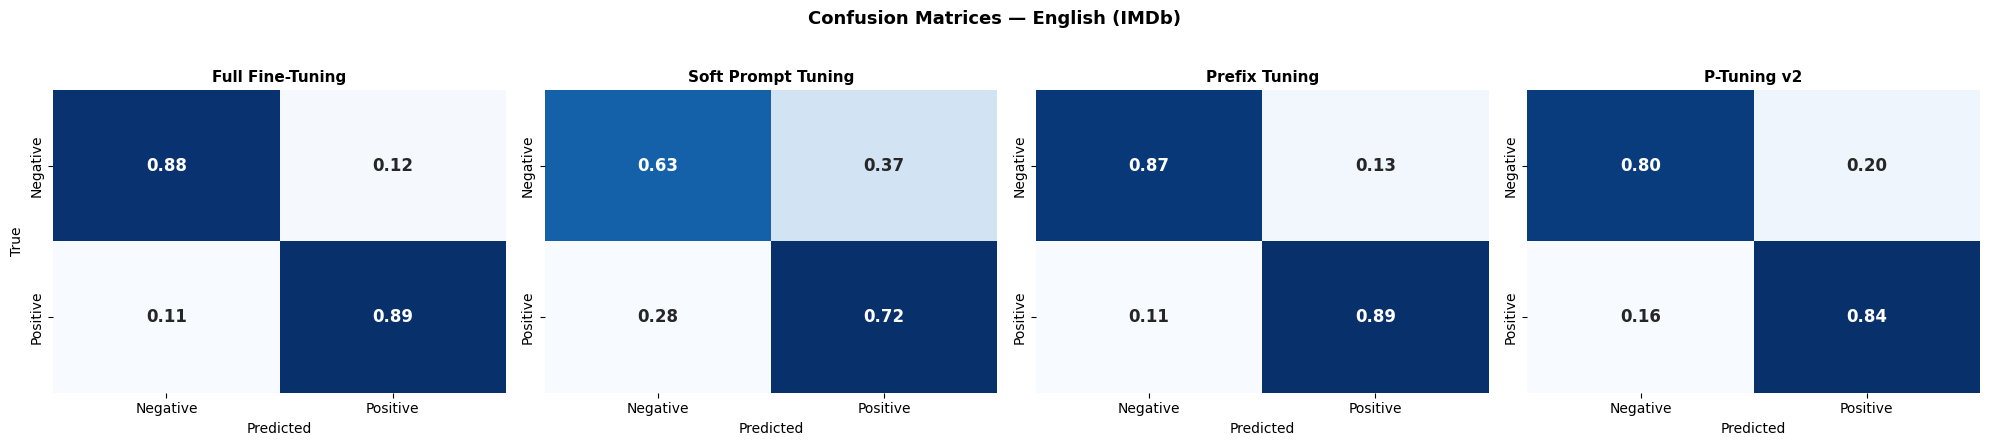

✅ Figure 5 saved


In [19]:
# ============================================================
# CELL 17: CONFUSION MATRICES (IEEE Figure 5)
# ============================================================

# Collect predictions from main experiments
en_methods_with_preds = {name: r for name, r in MAIN_RESULTS.items()
                          if name.startswith('EN_') and 'predictions' in r}

if len(en_methods_with_preds) > 0:
    n_methods = len(en_methods_with_preds)
    fig, axes = plt.subplots(1, n_methods, figsize=(5*n_methods, 4.5))
    if n_methods == 1:
        axes = [axes]
    fig.suptitle('Confusion Matrices — English (IMDb)\n',
                 fontsize=13, fontweight='bold')

    class_names = ['Negative', 'Positive'] if NUM_CLASSES_EN == 2 else \
                  [f'Class {i}' for i in range(NUM_CLASSES_EN)]

    for idx, (name, r) in enumerate(en_methods_with_preds.items()):
        cm = confusion_matrix(r['true_labels'], r['predictions'])
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    ax=axes[idx], cbar=False,
                    annot_kws={'size': 12, 'weight': 'bold'})
        axes[idx].set_title(r['method'], fontweight='bold', fontsize=11)
        axes[idx].set_ylabel('True' if idx == 0 else '')
        axes[idx].set_xlabel('Predicted')

    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/fig5_confusion_matrices.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Figure 5 saved")
else:
    print("⏭️ No predictions available for confusion matrices")

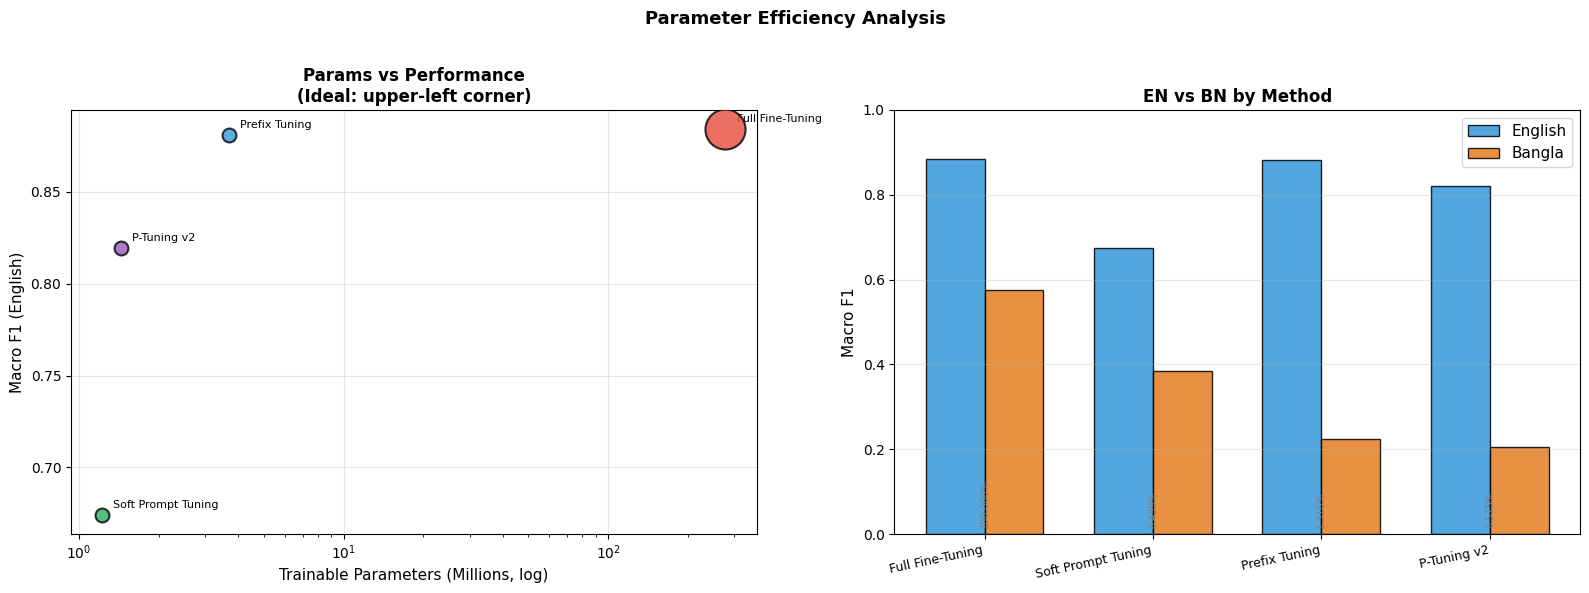

✅ Figure 6 saved


In [20]:
# ============================================================
# CELL 18: PARAMETER EFFICIENCY FIGURE (IEEE Figure 6)
# ============================================================

# Collect main results
param_rows = []
for name, r in MAIN_RESULTS.items():
    if name.startswith('EN_'):
        param_rows.append({
            'Method': r['method'],
            'Trainable_M': r['trainable_params'] / 1e6,
            'Param_Pct': r['param_pct'],
            'EN_F1': r['macro_f1'],
            'Time': r['train_time_min'],
        })

# Add Bangla if available
for name, r in MAIN_RESULTS.items():
    if name.startswith('BN_'):
        method = r['method']
        for pr in param_rows:
            if pr['Method'] == method:
                pr['BN_F1'] = r['macro_f1']

if len(param_rows) > 0:
    df_p = pd.DataFrame(param_rows)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Parameter Efficiency Analysis\n',
                 fontweight='bold', fontsize=13)

    colors_list = ['#e74c3c', '#27ae60', '#3498db', '#9b59b6']

    # Left: Bubble chart (params vs F1)
    for i, row in df_p.iterrows():
        size = max(100, row['Trainable_M'] * 3)
        axes[0].scatter(row['Trainable_M'], row['EN_F1'],
                        s=min(size, 1000), color=colors_list[i % len(colors_list)],
                        alpha=0.8, edgecolors='black', linewidth=1.5, zorder=5)
        axes[0].annotate(row['Method'],
                         (row['Trainable_M'], row['EN_F1']),
                         textcoords='offset points', xytext=(8, 5), fontsize=8)

    axes[0].set_xscale('log')
    axes[0].set_xlabel('Trainable Parameters (Millions, log)', fontsize=11)
    axes[0].set_ylabel('Macro F1 (English)', fontsize=11)
    axes[0].set_title('Params vs Performance\n(Ideal: upper-left corner)', fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Right: Grouped bar EN vs BN
    x = np.arange(len(df_p))
    w = 0.35
    b1 = axes[1].bar(x - w/2, df_p['EN_F1'], w, label='English', color='#3498db',
                     edgecolor='black', alpha=0.85)
    if 'BN_F1' in df_p.columns:
        b2 = axes[1].bar(x + w/2, df_p['BN_F1'], w, label='Bangla', color='#e67e22',
                         edgecolor='black', alpha=0.85)

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(df_p['Method'], rotation=12, ha='right', fontsize=9)
    axes[1].set_ylabel('Macro F1', fontsize=11)
    axes[1].set_title('EN vs BN by Method', fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].set_ylim(0, 1.0)
    axes[1].grid(True, axis='y', alpha=0.3)

    # Add param% annotation
    for i, row in df_p.iterrows():
        axes[1].text(i, 0.02, f"{row['Param_Pct']:.3f}%",
                     ha='center', fontsize=7, color='gray', rotation=90)

    plt.tight_layout()
    plt.savefig(f"{CFG['output_dir']}/fig6_param_efficiency.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Figure 6 saved")
else:
    print("⏭️ No parameter data to plot")

In [21]:
# ============================================================
# CELL 19: STATISTICAL SIGNIFICANCE TESTING
# ============================================================

def mcnemar_test(preds_a, preds_b, true_labels):
    correct_a = (np.array(preds_a) == np.array(true_labels))
    correct_b = (np.array(preds_b) == np.array(true_labels))
    only_a = np.sum(correct_a & ~correct_b)
    only_b = np.sum(~correct_a & correct_b)
    if only_a + only_b == 0:
        return 1.0
    chi2 = (abs(only_a - only_b) - 1)**2 / (only_a + only_b)
    return 1 - stats.chi2.cdf(chi2, df=1)

def bootstrap_ci(y_true, y_pred, n_boot=1000, alpha=0.05):
    scores = []
    n = len(y_true)
    yt, yp = np.array(y_true), np.array(y_pred)
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        s = f1_score(yt[idx], yp[idx], average='macro', zero_division=0)
        scores.append(s)
    lo = np.percentile(scores, 100 * alpha / 2)
    hi = np.percentile(scores, 100 * (1 - alpha / 2))
    return np.mean(scores), lo, hi

# Run significance tests between Fine-Tuning and each prompt method
print("="*65)
print("  STATISTICAL SIGNIFICANCE (McNemar + Bootstrap CI)")
print("="*65)

stat_results = []
ft_key = 'EN_finetune'

if ft_key in MAIN_RESULTS and 'predictions' in MAIN_RESULTS[ft_key]:
    ft_preds = MAIN_RESULTS[ft_key]['predictions']
    ft_true = MAIN_RESULTS[ft_key]['true_labels']

    # Bootstrap CI for fine-tuning
    mean_ft, lo_ft, hi_ft = bootstrap_ci(ft_true, ft_preds)
    print(f"\nFine-Tuning: F1={mean_ft:.4f} [95% CI: {lo_ft:.4f}, {hi_ft:.4f}]")

    for key in ['EN_soft_prompt', 'EN_prefix', 'EN_p_tuning_v2']:
        if key in MAIN_RESULTS and 'predictions' in MAIN_RESULTS[key]:
            other_preds = MAIN_RESULTS[key]['predictions']
            other_true = MAIN_RESULTS[key]['true_labels']

            p_val = mcnemar_test(ft_preds, other_preds, ft_true)
            mean_o, lo_o, hi_o = bootstrap_ci(other_true, other_preds)
            sig = "★ SIGNIFICANT" if p_val < 0.05 else "not significant"

            stat_results.append({
                'Comparison': f"FT vs {MAIN_RESULTS[key]['method']}",
                'p_value': round(p_val, 4),
                'significant': p_val < 0.05,
                'FT_F1_CI': f"{mean_ft:.4f} [{lo_ft:.4f}, {hi_ft:.4f}]",
                'Other_F1_CI': f"{mean_o:.4f} [{lo_o:.4f}, {hi_o:.4f}]",
            })

            print(f"\nFT vs {MAIN_RESULTS[key]['method']}:")
            print(f"  McNemar p-value: {p_val:.4f} → {sig}")
            print(f"  Other F1: {mean_o:.4f} [95% CI: {lo_o:.4f}, {hi_o:.4f}]")

    if stat_results:
        df_stat = pd.DataFrame(stat_results)
        df_stat.to_csv(f"{CFG['output_dir']}/statistical_significance.csv", index=False)
        print(f"\n Statistical results saved")
else:
    print(" Fine-tuning predictions not available")

  STATISTICAL SIGNIFICANCE (McNemar + Bootstrap CI)

Fine-Tuning: F1=0.8841 [95% CI: 0.8804, 0.8879]

FT vs Soft Prompt Tuning:
  McNemar p-value: 0.0000 → ★ SIGNIFICANT
  Other F1: 0.6742 [95% CI: 0.6683, 0.6797]

FT vs Prefix Tuning:
  McNemar p-value: 0.0845 → not significant
  Other F1: 0.8812 [95% CI: 0.8772, 0.8853]

FT vs P-Tuning v2:
  McNemar p-value: 0.0000 → ★ SIGNIFICANT
  Other F1: 0.8197 [95% CI: 0.8149, 0.8244]

 Statistical results saved


In [22]:
# ============================================================
# CELL 20: GENERATE IEEE PAPER TABLES (LaTeX + CSV + Excel)
# ============================================================

# ─── TABLE 2: Main Results ───
print("="*70)
print("  TABLE 2 — MAIN RESULTS")
print("="*70)

table2_rows = []
for name, r in sorted(MAIN_RESULTS.items()):
    lang = 'EN' if name.startswith('EN_') else 'BN'
    dataset = 'IMDb' if lang == 'EN' else 'Bangla'
    table2_rows.append({
        'Method': r['method'],
        'Dataset': dataset,
        'Language': lang,
        'Accuracy': r['accuracy'],
        'Macro_F1': r['macro_f1'],
        'Weighted_F1': r['weighted_f1'],
        'Param_Pct': r['param_pct'],
        'Time_min': r['train_time_min'],
    })

df_table2 = pd.DataFrame(table2_rows)
df_table2.to_csv(f"{CFG['output_dir']}/table2_main_results.csv", index=False)
df_table2.to_excel(f"{CFG['output_dir']}/table2_main_results.xlsx", index=False)

# Print nicely
print(f"{'Method':<22} {'Data':<8} {'Acc':<8} {'F1':<8} {'Params%':<10} {'Time'}")
print("-"*65)
for _, row in df_table2.iterrows():
    print(f"{row['Method']:<22} {row['Dataset']:<8} {row['Accuracy']:<8.4f} "
          f"{row['Macro_F1']:<8.4f} {row['Param_Pct']:<10.4f} {row['Time_min']}min")

# ─── Generate LaTeX ───
latex_lines = [
    "\\begin{table}[htbp]",
    "\\centering",
    "\\caption{Main Results: Prompt Tuning vs Fine-Tuning}",
    "\\label{tab:main}",
    "\\begin{tabular}{llcccc}",
    "\\toprule",
    "Method & Dataset & Accuracy & Macro F1 & Params\\% & Time \\\\",
    "\\midrule",
]

prev_dataset = ''
for _, row in df_table2.iterrows():
    if row['Dataset'] != prev_dataset and prev_dataset != '':
        latex_lines.append("\\midrule")
    prev_dataset = row['Dataset']

    # Bold best F1 per dataset
    latex_lines.append(
        f"{row['Method']} & {row['Dataset']} & {row['Accuracy']:.4f} & "
        f"{row['Macro_F1']:.4f} & {row['Param_Pct']:.3f} & {row['Time_min']}min \\\\"
    )

latex_lines.extend([
    "\\bottomrule",
    "\\end{tabular}",
    "\\end{table}"
])

latex_code = "\n".join(latex_lines)
print("\n📄 LaTeX Code:")
print(latex_code)

with open(f"{CFG['output_dir']}/table2_main.tex", 'w') as f:
    f.write(latex_code)

# ─── TABLE 3: Data Efficiency ───
if os.path.exists(f"{CFG['output_dir']}/data_efficiency_results.csv"):
    df_eff = pd.read_csv(f"{CFG['output_dir']}/data_efficiency_results.csv")
    print("\n\n" + "="*70)
    print("  TABLE 3 — DATA EFFICIENCY RESULTS")
    print("="*70)

    pivot = df_eff.pivot_table(index='method', columns='sample_size',
                                values='macro_f1', aggfunc='first')
    print(pivot.to_string())
    pivot.to_csv(f"{CFG['output_dir']}/table3_data_efficiency.csv")
    pivot.to_excel(f"{CFG['output_dir']}/table3_data_efficiency.xlsx")

    # LaTeX
    latex3 = pivot.to_latex(float_format="%.4f",
                            caption="Data Efficiency Results (Macro F1)",
                            label="tab:efficiency")
    with open(f"{CFG['output_dir']}/table3_efficiency.tex", 'w') as f:
        f.write(latex3)

# ─── TABLE 4: Ablation ───
if os.path.exists(f"{CFG['output_dir']}/ablation_prompt_length.csv"):
    df_abl = pd.read_csv(f"{CFG['output_dir']}/ablation_prompt_length.csv")
    print("\n\n" + "="*70)
    print("  TABLE 4 — ABLATION: PROMPT LENGTH")
    print("="*70)
    cols = ['prompt_length', 'macro_f1', 'accuracy', 'train_time_min', 'trainable_params']
    cols = [c for c in cols if c in df_abl.columns]
    print(df_abl[cols].to_string(index=False))

print(f"\n All tables saved to {CFG['output_dir']}/")

  TABLE 2 — MAIN RESULTS
Method                 Data     Acc      F1       Params%    Time
-----------------------------------------------------------------
Full Fine-Tuning       Bangla   0.6164   0.5759   100.0000   132.18min
P-Tuning v2            Bangla   0.4460   0.2056   0.5157     164.75min
Prefix Tuning          Bangla   0.4474   0.2235   1.3161     165.97min
Soft Prompt Tuning     Bangla   0.4744   0.3838   0.4393     178.03min
Full Fine-Tuning       IMDb     0.8841   0.8841   100.0000   69.38min
P-Tuning v2            IMDb     0.8196   0.8196   0.5151     106.2min
Prefix Tuning          IMDb     0.8810   0.8810   1.3156     99.67min
Soft Prompt Tuning     IMDb     0.6747   0.6741   0.4387     96.36min

📄 LaTeX Code:
\begin{table}[htbp]
\centering
\caption{Main Results: Prompt Tuning vs Fine-Tuning}
\label{tab:main}
\begin{tabular}{llcccc}
\toprule
Method & Dataset & Accuracy & Macro F1 & Params\% & Time \\
\midrule
Full Fine-Tuning & Bangla & 0.6164 & 0.5759 & 100.000 & 132.1

In [23]:
# ============================================================
# CELL 21: ★ FINAL SUMMARY + CHECKLIST ★
# ============================================================

print("\n" + "╔" + "═"*60 + "╗")
print("║" + "  IEEE PAPER — COMPLETE RESULTS SUMMARY".center(60) + "║")
print("╠" + "═"*60 + "╣")

# Check what we have
files = os.listdir(CFG['output_dir']) if os.path.exists(CFG['output_dir']) else []

checks = [
    ("Dataset: IMDb (English)",           True),
    ("Dataset: Bangla Sentiment",          bangla_loaded),
    ("Method: Full Fine-Tuning",           'EN_finetune' in MAIN_RESULTS),
    ("Method: Soft Prompt Tuning",         'EN_soft_prompt' in MAIN_RESULTS),
    ("Method: Prefix Tuning",              'EN_prefix' in MAIN_RESULTS),
    ("Method: P-Tuning v2",               'EN_p_tuning_v2' in MAIN_RESULTS),
    ("Bangla Fine-Tuning",                'BN_finetune' in MAIN_RESULTS),
    ("Bangla Prompt Tuning",              'BN_soft_prompt' in MAIN_RESULTS),
    ("Data Efficiency Experiment",         len(DATA_EFF_RESULTS) > 0),
    ("Ablation Study",                     len(ABLATION_RESULTS) > 0),
    ("Cross-Lingual Transfer",            len(CROSSLINGUAL_RESULTS) > 0),
    ("Statistical Significance",          any('statistical' in f for f in files)),
    ("Figure 1: Dataset Stats",           'fig1_dataset_stats.png' in files),
    ("Figure 2: Data Efficiency",         'fig2_data_efficiency.png' in files),
    ("Figure 3: Cross-Lingual",           'fig3_crosslingual.png' in files),
    ("Figure 4: Ablation",               'fig4_ablation.png' in files),
    ("Figure 5: Confusion Matrices",      'fig5_confusion_matrices.png' in files),
    ("Figure 6: Parameter Efficiency",    'fig6_param_efficiency.png' in files),
    ("LaTeX Tables",                       any('.tex' in f for f in files)),
    ("Excel Tables",                       any('.xlsx' in f for f in files)),
]

for item, done in checks:
    status = "✅" if done else "❌"
    print(f"║  {status} {item:<50}      ║")

print("╠" + "═"*60 + "╣")
print("║" + f"  Total experiments run: {len(ALL_RESULTS)}".ljust(60) + "║")
print("║" + f"  Output directory: {CFG['output_dir']}".ljust(60) + "║")
print("╚" + "═"*60 + "╝")

# List all output files
print("\n📁 Output Files:")
for f in sorted(files):
    size = os.path.getsize(f"{CFG['output_dir']}/{f}")
    print(f"  {f:<50} ({size/1024:.1f} KB)")

# ── Key findings summary ──
print("\n" + "="*60)
print("  KEY FINDINGS FOR PAPER")
print("="*60)

if len(MAIN_RESULTS) >= 4:
    en_results = {k: v for k, v in MAIN_RESULTS.items() if k.startswith('EN_')}
    if en_results:
        best_en = max(en_results.items(), key=lambda x: x[1]['macro_f1'])
        print(f"  Best English method: {best_en[1]['method']} (F1={best_en[1]['macro_f1']:.4f})")

        ft_f1 = MAIN_RESULTS.get('EN_finetune', {}).get('macro_f1', 0)
        spt_f1 = MAIN_RESULTS.get('EN_soft_prompt', {}).get('macro_f1', 0)
        ft_params = MAIN_RESULTS.get('EN_finetune', {}).get('param_pct', 100)
        spt_params = MAIN_RESULTS.get('EN_soft_prompt', {}).get('param_pct', 0)

        print(f"\n  Fine-Tuning:     F1={ft_f1:.4f} | Params={ft_params:.3f}%")
        print(f"  Soft Prompt:     F1={spt_f1:.4f} | Params={spt_params:.4f}%")
        print(f"  Param Reduction: {ft_params/max(spt_params,0.001):.0f}x fewer parameters")
        print(f"  F1 Gap:          {abs(ft_f1 - spt_f1):.4f}")

        if abs(ft_f1 - spt_f1) < 0.03:
            print(f"\n  📌 FINDING: Prompt tuning achieves NEAR PARITY with fine-tuning")
            print(f"     using {ft_params/max(spt_params,0.001):.0f}x fewer trainable parameters!")

print("\n✅ Notebook complete! Copy figures and tables to your IEEE paper.")


╔════════════════════════════════════════════════════════════╗
║            IEEE PAPER — COMPLETE RESULTS SUMMARY           ║
╠════════════════════════════════════════════════════════════╣
║  ✅ Dataset: IMDb (English)                                 ║
║  ✅ Dataset: Bangla Sentiment                               ║
║  ✅ Method: Full Fine-Tuning                                ║
║  ✅ Method: Soft Prompt Tuning                              ║
║  ✅ Method: Prefix Tuning                                   ║
║  ✅ Method: P-Tuning v2                                     ║
║  ✅ Bangla Fine-Tuning                                      ║
║  ✅ Bangla Prompt Tuning                                    ║
║  ✅ Data Efficiency Experiment                              ║
║  ✅ Ablation Study                                          ║
║  ✅ Cross-Lingual Transfer                                  ║
║  ✅ Statistical Significance                                ║
║  ✅ Figure 1: Dataset Stats                          

In [ ]:
# ============================================================
# CELL 22: IEEE PAPER OUTLINE + REFERENCES
# ============================================================

paper_outline = """
╔══════════════════════════════════════════════════════════════╗
║              IEEE PAPER STRUCTURE                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  I. INTRODUCTION                                             ║
║     - NLP for low-resource languages (Bangla)                ║
║     - Parameter-efficient methods motivation                 ║
║     - Contributions (3 bullet points)                        ║
║                                                              ║
║  II. RELATED WORK                                            ║
║     A. Bangla NLP & Sentiment Analysis                       ║
║     B. Parameter-Efficient Fine-Tuning (PEFT)                ║
║     C. Cross-Lingual Transfer Learning                       ║
║                                                              ║
║  III. METHODOLOGY                                            ║
║     A. Full Fine-Tuning (baseline)                           ║
║     B. Soft Prompt Tuning                                    ║
║     C. Prefix Tuning                                         ║
║     D. P-Tuning v2                                           ║
║     (Include architecture diagram - Figure 1)                ║
║                                                              ║
║  IV. EXPERIMENTAL SETUP                                      ║
║     A. Datasets (Table 1: stats)                             ║
║     B. Models: XLM-RoBERTa-base                              ║
║     C. Hyperparameters (Table: lr, epochs, etc.)             ║
║     D. Evaluation Metrics                                    ║
║                                                              ║
║  V. RESULTS & ANALYSIS                                       ║
║     A. Main Results (Table 2 + Figure)                       ║
║     B. Data Efficiency (Figure 2 - KEY CONTRIBUTION)         ║
║     C. Cross-Lingual Transfer (Table 3 + Figure 3)           ║
║     D. Ablation Study (Table 4 + Figure 4)                   ║
║     E. Error Analysis (Figure 5: confusion matrices)         ║
║     F. Parameter Efficiency (Figure 6)                       ║
║     G. Statistical Significance                              ║
║                                                              ║
║  VI. DISCUSSION                                              ║
║     - When does prompt tuning win?                           ║
║     - Low-resource advantage                                 ║
║     - Limitations                                            ║
║                                                              ║
║  VII. CONCLUSION & FUTURE WORK                               ║
║                                                              ║
║  REFERENCES (12-15 papers)                                   ║
╚══════════════════════════════════════════════════════════════╝

KEY REFERENCES:
[1] Lester et al. (2021) "The Power of Scale for Parameter-Efficient
    Prompt Tuning" - EMNLP. arXiv:2104.08691
[2] Li & Liang (2021) "Prefix-Tuning" - ACL. arXiv:2101.00190
[3] Liu et al. (2022) "P-Tuning v2" - arXiv:2110.07602
[4] Conneau et al. (2020) "XLM-RoBERTa" - ACL. arXiv:1911.02116
[5] Hasan et al. (2023) "Zero/Few-Shot vs Fine-Tuned for Bangla
    Sentiment" - arXiv:2308.10783
[6] BLP-2023 Shared Task 2 - arXiv:2311.15032
[7] Hu et al. (2022) "LoRA" - ICLR. arXiv:2106.09685
[8] Islam et al. (2021) "SentNoB" - EMNLP Findings
[9] Maas et al. (2011) "IMDb dataset" - ACL
[10] Devlin et al. (2019) "BERT" - NAACL

TO SUBMIT:
- IEEE Access: https://ieeeaccess.ieee.org/
- BLP Workshop @ EMNLP: https://blp-workshop.github.io/
- COLING 2026
- LREC-COLING 2024/2025

PAGE LIMIT: Usually 6-8 pages (conference) or 15+ (IEEE Access)
"""

print(paper_outline)

# Save references
with open(f"{CFG['output_dir']}/references.txt", 'w') as f:
    f.write(paper_outline)
print("✅ Paper outline saved")

In [ ]:
1️⃣  Google Colab খোলো → GPU Runtime select করো (T4 বা A100)
2️⃣  উপরের ক্রমে 22টি cell তৈরি করো
3️⃣  Cell 3 তে TEST_MODE=True দিয়ে আগে test করো
4️⃣  সব ঠিক চললে TEST_MODE=False করে full run দাও
5️⃣  ./results/ ফোল্ডারে সব figure + table পাবে
6️⃣  LaTeX table সরাসরি paper-এ copy-paste করো

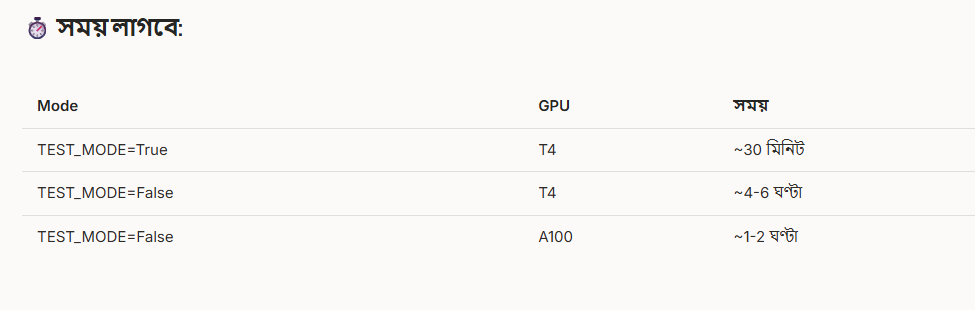

In [ ]:
results/
├── fig1_dataset_stats.png        ← IEEE Figure 1
├── fig2_data_efficiency.png      ← IEEE Figure 2 (Main!)
├── fig3_crosslingual.png         ← IEEE Figure 3
├── fig4_ablation.png             ← IEEE Figure 4
├── fig5_confusion_matrices.png   ← IEEE Figure 5
├── fig6_param_efficiency.png     ← IEEE Figure 6
├── table2_main_results.xlsx      ← Copy to paper
├── table2_main.tex               ← LaTeX table
├── table3_data_efficiency.xlsx
├── all_results.csv               ← Complete log
├── statistical_significance.csv
└── references.txt

In [ ]:
# fix notebook